# The Attention Mechanism: From Problem to Solution

## The Problem We're Solving

In Phase 5, we saw how the Seq2Seq LSTM encoder compresses an entire input sequence into a single fixed-size context vector `h_n`. The decoder must then regenerate the full output from just that one vector. When the input sequence is long, `h_n` simply cannot hold all the relevant information. Accuracy collapsed dramatically.

The intuition behind Attention is: **why should the decoder only look at one final state?** The encoder produces a hidden state at *every single timestep*. When the decoder is generating the 3rd output word, it doesn't need to know equally about all input words — it should *focus* (pay attention) on the most relevant parts. That's attention.

---

## Query, Key, and Value: The Core Abstraction

Attention is often explained with a retrieval analogy from databases. Imagine a dictionary:

In [ ]:
library = {
    "machine learning": "A field of AI...",
    "neural networks":  "A computing system...",
    "deep learning":    "A subset of ML...",
}

In a **hard lookup**, you send an exact query key ("machine learning") and get back exactly one value. In **soft attention**, you send a fuzzy query and get back a *weighted blend* of all values, where the weights depend on how relevant each key is to your query.

In a Transformer:
- **Query (Q):** "What am I looking for?" — comes from the current token
- **Key (K):** "What do I contain?" — comes from each token in the sequence  
- **Value (V):** "What information do I actually provide?" — also from each token

The output for a query is a weighted average of all values, where the weights are determined by how similar the query is to each key.

---

## Scaled Dot-Product Attention: The Math Made Concrete

The attention formula is:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

Let's break down exactly what each operation does:

1. **`Q K^T` (dot product):** Measures similarity between the query and every key. If Q and K point in similar directions in embedding space, their dot product is large (relevant). If they're orthogonal, the dot product is near zero (irrelevant).

2. **`/ √d_k` (scaling):** The dot products can become very large when `d_k` is large (e.g., 512), which pushes the softmax into regions with extremely small gradients. Dividing by `√d_k` keeps them in a well-behaved range.

3. **`softmax(...)` (normalization):** Converts raw similarity scores into a probability distribution that sums to 1. The most relevant tokens get scores close to 1, irrelevant ones get scores close to 0.

4. **`... V` (weighted sum):** The output is a weighted combination of all values. If token 5 got an attention weight of 0.7, then 70% of the output comes from token 5's value vector.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, seq_len_q, d_k)  — the "what am I looking for" vector
    K: (batch, seq_len_k, d_k)  — the "what do I contain" vectors
    V: (batch, seq_len_k, d_v)  — the "what do I give you" vectors
    mask: optional boolean mask — positions marked True are blocked (set to -inf before softmax)
    
    Returns:
        output:  (batch, seq_len_q, d_v)  — the attended-over values
        weights: (batch, seq_len_q, seq_len_k) — the attention weights (useful to visualize!)
    """
    d_k = Q.size(-1)  # Key/query dimension
    
    # Step 1: Score = Q @ K^T. Result shape: (batch, seq_len_q, seq_len_k)
    # scores[b, i, j] = "how much does query position i attend to key position j?"
    scores = torch.matmul(Q, K.transpose(-2, -1))
    
    # Step 2: Scale to prevent vanishing gradients in softmax
    scores = scores / (d_k ** 0.5)
    
    # Step 3: Apply mask (used for causal/padding masking)
    if mask is not None:
        # Replace masked positions with -inf so softmax makes them ~0
        scores = scores.masked_fill(mask == 0, float('-inf'))
    
    # Step 4: Softmax turns scores into weights summing to 1 along the key dimension
    weights = F.softmax(scores, dim=-1)
    
    # Step 5: Weighted sum of values
    output = torch.matmul(weights, V)
    
    return output, weights


# --- Concrete Example: A 5-token sequence ---
batch_size = 1
seq_len    = 5
d_k        = 8   # Dimension of Q and K vectors
d_v        = 8   # Dimension of V vectors (can be different from d_k, but often same)

torch.manual_seed(0)
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_v)

output, weights = scaled_dot_product_attention(Q, K, V)
print(f"Q shape:      {Q.shape}")
print(f"K shape:      {K.shape}")
print(f"V shape:      {V.shape}")
print(f"Output shape: {output.shape}")   # (1, 5, 8) — one attended vector per token
print(f"Weights shape:{weights.shape}")  # (1, 5, 5) — 5×5 attention matrix

# The weights matrix tells you the full story:
# weights[0, i, j] = "how much did token i attend to token j?"
print("\nAttention weights (row = query token, col = key token):")
print(weights[0].detach().round(decimals=3))
# Each ROW sums to 1.0 (it's a probability distribution)

Q shape:      torch.Size([1, 5, 8])
K shape:      torch.Size([1, 5, 8])
V shape:      torch.Size([1, 5, 8])
Output shape: torch.Size([1, 5, 8])
Weights shape:torch.Size([1, 5, 5])

Attention weights (row = query token, col = key token):
tensor([[0.6150, 0.0690, 0.0210, 0.0380, 0.2560],
        [0.4750, 0.1140, 0.0680, 0.1550, 0.1880],
        [0.0430, 0.4050, 0.0590, 0.3530, 0.1390],
        [0.0970, 0.2410, 0.1040, 0.3530, 0.2060],
        [0.0620, 0.1560, 0.2470, 0.4940, 0.0410]])


---

## Visualizing Attention Weights

The attention weight matrix is one of the most powerful interpretability tools in NLP. In a well-trained model, you can literally *see* what each token is looking at.

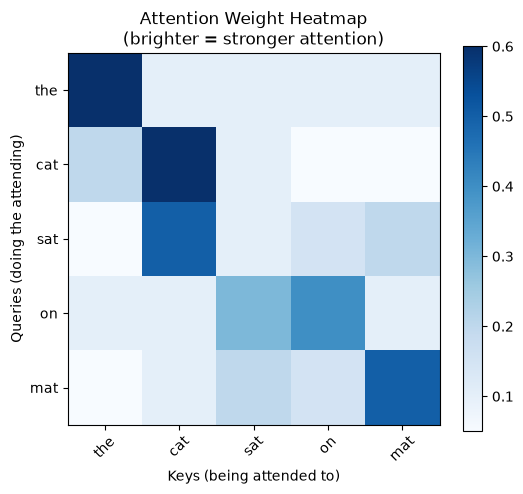

In [2]:
# Simulate a sentence: "the cat sat on mat"
tokens = ["the", "cat", "sat", "on", "mat"]

# Create a fake "trained" attention pattern where "sat" (index 2) 
# strongly attends to "cat" (the subject) and "mat" (the object)
attn = torch.tensor([[
    [0.6, 0.1, 0.1, 0.1, 0.1],  # "the" mostly looks at itself
    [0.2, 0.6, 0.1, 0.05, 0.05], # "cat" looks at itself and "the"
    [0.05, 0.5, 0.1, 0.15, 0.2], # "sat" attends to "cat" and "mat"
    [0.1, 0.1, 0.3, 0.4, 0.1],   # "on" attends to "sat" and itself
    [0.05, 0.1, 0.2, 0.15, 0.5], # "mat" attends to itself and "sat"
]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn[0], cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45)
ax.set_yticklabels(tokens)
ax.set_xlabel("Keys (being attended to)")
ax.set_ylabel("Queries (doing the attending)")
ax.set_title("Attention Weight Heatmap\n(brighter = stronger attention)")
plt.colorbar(im)
# plt.show()

---

## Causal (Masked) Attention: How GPT Works

In a GPT-style language model, we predict the next token based on all *previous* tokens. When training, we process the whole sequence at once (for efficiency), but token at position `i` must **not** be allowed to see tokens at positions `i+1, i+2, ...` — that would be cheating (looking at the future answer during training).

We enforce this with a **causal mask**: a lower-triangular matrix of 1s and 0s. Positions set to 0 in the mask get filled with `-inf` before the softmax, which makes them attend with weight ~0.

In [3]:
seq_len = 5

# Lower triangular matrix: 1s on and below the diagonal, 0s above
# Position i can only attend to positions 0..i
causal_mask = torch.tril(torch.ones(seq_len, seq_len))
print("Causal Mask (1=allowed, 0=blocked):")
print(causal_mask.int())

# Apply it in practice
Q_causal = torch.randn(1, seq_len, d_k)
K_causal = torch.randn(1, seq_len, d_k)
V_causal = torch.randn(1, seq_len, d_v)

# Expand mask to (1, seq_len, seq_len) to broadcast over the batch dimension
output_causal, weights_causal = scaled_dot_product_attention(
    Q_causal, K_causal, V_causal, mask=causal_mask
)

print("\nCausal Attention Weights (each row sums to 1, zeros above diagonal):")
print(weights_causal[0].detach().round(decimals=3))
# Notice: upper triangle is 0.0. Token 0 only looks at itself.
# Token 4 can look at all 5 tokens. This is autoregressive generation!

# Verify each row still sums to 1
print("\nRow sums:", weights_causal[0].sum(dim=-1).tolist())

Causal Mask (1=allowed, 0=blocked):
tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)

Causal Attention Weights (each row sums to 1, zeros above diagonal):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5030, 0.4970, 0.0000, 0.0000, 0.0000],
        [0.1190, 0.5790, 0.3020, 0.0000, 0.0000],
        [0.3230, 0.4160, 0.0220, 0.2390, 0.0000],
        [0.3530, 0.1040, 0.0330, 0.4070, 0.1030]])

Row sums: [1.0, 1.0, 1.0, 1.0, 1.0]


---

## The Effect of Removing the Scaling Factor

This is a common exam question and a real engineering pitfall. Here's what actually happens:

In [13]:
# Without scaling
def attention_no_scale(Q, K, V):
    scores = torch.matmul(Q, K.transpose(-2, -1))  # No /sqrt(d_k)
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

# Use a larger d_k to amplify the effect
d_k_large = 64
Q_large = torch.randn(1, 5, d_k_large)
K_large = torch.randn(1, 5, d_k_large)
V_large = torch.randn(1, 5, d_k_large)

_, weights_unscaled = attention_no_scale(Q_large, K_large, V_large)
_, weights_scaled   = scaled_dot_product_attention(Q_large, K_large, V_large)

# The unscaled weights will be "peakier" — one token gets nearly all the weight
# because the dot products are huge numbers, making softmax very confident
print("Unscaled max attention weight (per query):", weights_unscaled[0].max(dim=-1).values.tolist())
print("Scaled   max attention weight (per query):", weights_scaled[0].max(dim=-1).values.tolist())
# Unscaled: values close to 1.0 → very sharp, near one-hot attention
# Scaled: more distributed → richer information gathering

Unscaled max attention weight (per query): [0.9379249811172485, 0.9001636505126953, 0.9972882270812988, 0.9746379256248474, 0.9795284271240234]
Scaled   max attention weight (per query): [0.42422229051589966, 0.3947910964488983, 0.5658510327339172, 0.44471973180770874, 0.42725270986557007]


When attention weights collapse to near one-hot distributions, the gradient through `softmax` becomes nearly zero (saturated region). The model effectively can't learn — it's stuck attending to the same one token no matter what.

---
## References
*   [Vaswani et al. (2017): Attention Is All You Need](https://arxiv.org/abs/1706.03762) — The original Transformer paper. Must-read.
*   [Jay Alammar: The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) — Best visual explanation
*   [3Blue1Brown: Attention in transformers, visually explained](https://www.youtube.com/watch?v=eMlx5fFNoYc)